**Problem Definition**

Main Problem

Predict traffic volume/congestion using historical traffic data.

Questions
What times have highest congestion?
Which factors affect traffic most?
Can machine learning accurately predict traffic flow?
Hypothesis

Traffic congestion depends on the Time and Day

In [115]:
import pandas as pd
import os

path = kagglehub.dataset_download("hasibullahaman/traffic-prediction-dataset")

print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'traffic-prediction-dataset' dataset.
/kaggle/input/traffic-prediction-dataset
['Traffic.csv', 'TrafficTwoMonth.csv']


In [116]:
df1 = pd.read_csv(os.path.join(path, "Traffic.csv"))
df2 = pd.read_csv(os.path.join(path, "TrafficTwoMonth.csv"))

In [117]:
#df1[:10]
#df2[:10]
df = pd.concat([df1, df2], ignore_index=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df[:10]

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal
5,1:15:00 AM,10,Tuesday,44,0,5,4,53,low
6,1:30:00 AM,10,Tuesday,37,0,1,4,42,low
7,1:45:00 AM,10,Tuesday,42,4,4,5,55,low
8,2:00:00 AM,10,Tuesday,51,0,9,7,67,low
9,2:15:00 AM,10,Tuesday,34,0,4,7,45,low


In [118]:
df.isnull().sum()

,0
Time,0
Date,0
Day of the week,0
CarCount,0
BikeCount,0
BusCount,0
TruckCount,0
Total,0
Traffic Situation,0


In [119]:
#el doctor 2al law mafeesh data bayza, 7ot data wes5a wy shelha tani. this code adds 10 null values in each column
import numpy as np
for col in df.columns:
    null_indices = np.random.choice(df.index, 10, replace=False)
    df.loc[null_indices, col] = np.nan
df.isnull().sum()

,0
Time,10
Date,10
Day of the week,10
CarCount,10
BikeCount,10
BusCount,10
TruckCount,10
Total,10
Traffic Situation,10


In [120]:
df.dropna(inplace=True)
df.isnull().sum()

,0
Time,0
Date,0
Day of the week,0
CarCount,0
BikeCount,0
BusCount,0
TruckCount,0
Total,0
Traffic Situation,0


In [121]:
df.info()
df.describe()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 6235 entries, 0 to 6322
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               6235 non-null   object 
 1   Date               6235 non-null   float64
 2   Day of the week    6235 non-null   object 
 3   CarCount           6235 non-null   float64
 4   BikeCount          6235 non-null   float64
 5   BusCount           6235 non-null   float64
 6   TruckCount         6235 non-null   float64
 7   Total              6235 non-null   float64
 8   Traffic Situation  6235 non-null   object 
dtypes: float64(6), object(3)
memory usage: 487.1+ KB
(6235, 9)


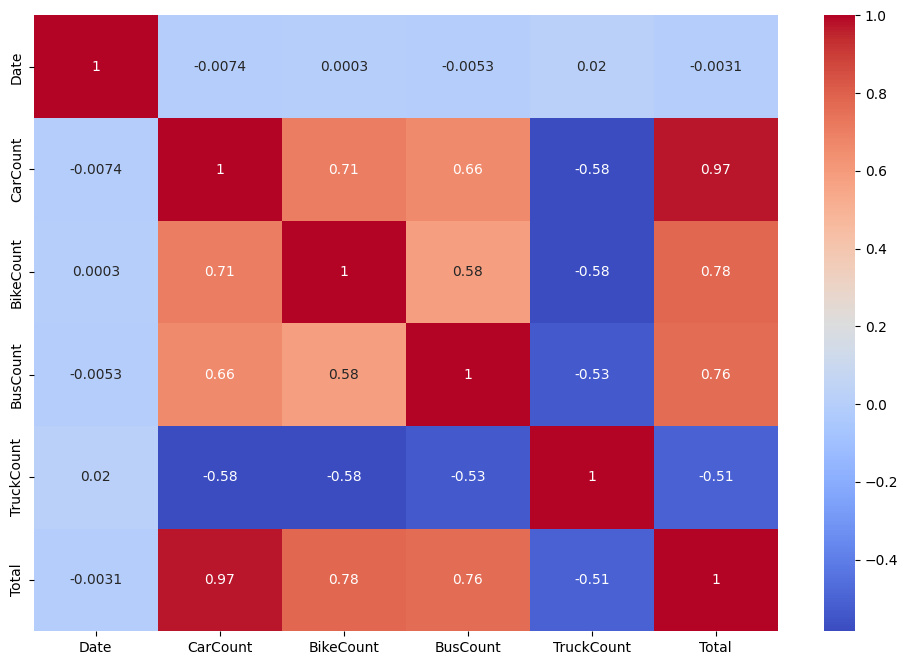

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

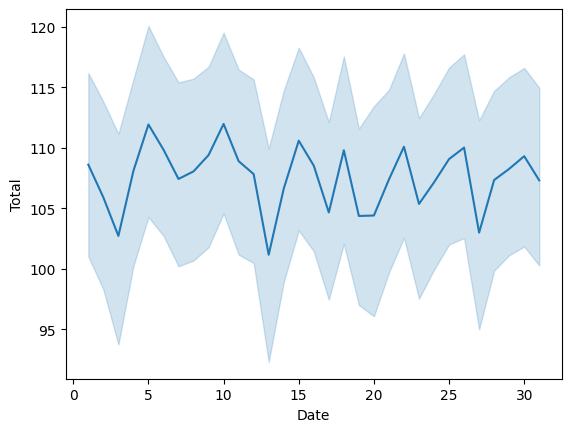

In [123]:
sns.lineplot(x='Date',
             y='Total',
             data=df)
plt.show()

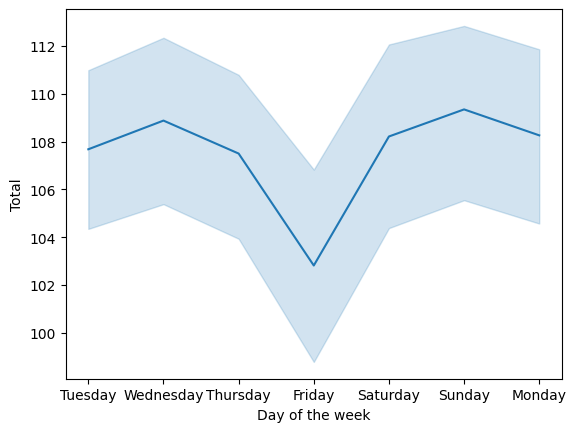

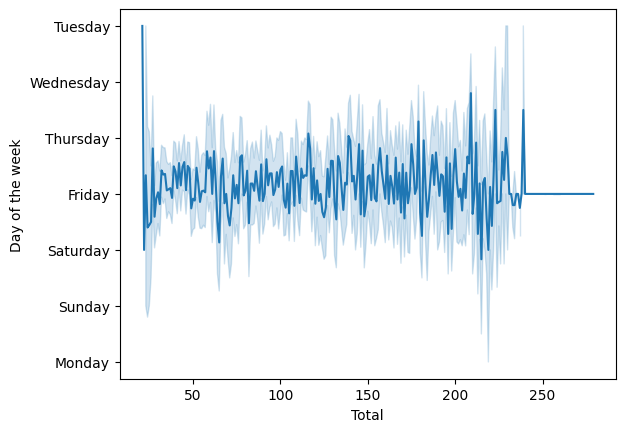

In [124]:
sns.lineplot(x='Day of the week',y='Total',data=df)
plt.show()
sns.lineplot(x='Total',y='Day of the week',data=df)
plt.show()

In [125]:
df['Time'] = pd.to_datetime(df['Time'])

df['Time'] = (
    df['Time'].dt.hour +
    df['Time'].dt.minute / 60
)

/tmp/ipykernel_10243/3096402891.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [127]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [128]:
y_pred = model.predict(X_test)

In [129]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 2.791899342368046e-14
MSE: 1.232394051647409e-27
